In [1]:
# ============================================
# UNIT 4: WATER TREATMENT CLASSIFICATION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully.")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Saving WATER_TREAT_23102020144712652.csv to WATER_TREAT_23102020144712652.csv
Dataset loaded successfully!
Shape: (382, 15)


,VAR,Variable,COU,Country,YEA,Year,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
0,TOTPUBSEW,Total public sewerage (% of resident populatio...,AUS,Australia,2017,2017,PC,Percentage,0,Units,NaN,NaN,92.69,NaN,NaN
1,TOTPUBSEW,Total public sewerage (% of resident populatio...,AUS,Australia,2018,2018,PC,Percentage,0,Units,NaN,NaN,92.64,NaN,NaN
2,TOTPUBSEW,Total public sewerage (% of resident populatio...,AUT,Austria,2018,2018,PC,Percentage,0,Units,NaN,NaN,100.00,NaN,NaN
3,TOTPUBSEW,Total public sewerage (% of resident populatio...,BEL,Belgium,2017,2017,PC,Percentage,0,Units,NaN,NaN,88.00,NaN,NaN
4,TOTPUBSEW,Total public sewerage (% of resident populatio...,CAN,Canada,2017,2017,PC,Percentage,0,Units,NaN,NaN,85.70,NaN,NaN


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nUnique variables:")
print(df["Variable"].nunique())

print("\nVariable categories:")
print(df["Variable"].value_counts())

Column names:
['VAR', 'Variable', 'COU', 'Country', 'YEA', 'Year', 'Unit Code', 'Unit', 'PowerCode Code', 'PowerCode', 'Reference Period Code', 'Reference Period', 'Value', 'Flag Codes', 'Flags']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VAR                    382 non-null    object 
 1   Variable               382 non-null    object 
 2   COU                    382 non-null    object 
 3   Country                382 non-null    object 
 4   YEA                    382 non-null    int64  
 5   Year                   382 non-null    int64  
 6   Unit Code              382 non-null    object 
 7   Unit                   382 non-null    object 
 8   PowerCode Code         382 non-null    int64  
 9   PowerCode              382 non-null    object 
 10  Reference Period Code  0 non-null      float64
 

In [ ]:
# Convert Value to numeric
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Remove rows where the target value is missing
df = df.dropna(subset=["Value"]).copy()

# Select features
features = ["Country", "Year", "Variable"]

X = df[features].copy()
y_value = df["Value"].copy()

# Split data before calculating the threshold
X_train, X_test, y_value_train, y_value_test = train_test_split(
    X,
    y_value,
    test_size=0.20,
    random_state=42
)

# Calculate threshold using training data only
threshold = y_value_train.median()

# Create binary target
y_train = (y_value_train >= threshold).astype(int)
y_test = (y_value_test >= threshold).astype(int)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Classification threshold:", round(threshold, 2))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 305
Testing samples: 77
Classification threshold: 19.0

Training class distribution:
Value
1    153
0    152
Name: count, dtype: int64

Testing class distribution:
Value
0    40
1    37
Name: count, dtype: int64


In [ ]:
categorical_features = ["Country", "Variable"]
numerical_features = ["Year"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ))
            ]),
            categorical_features
        ),
        (
            "numerical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (305, 38)
Processed testing shape: (77, 38)


In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(64, activation="relu"),
    Dropout(0.20),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9508 - loss: 0.1654 - val_accuracy: 0.9180 - val_loss: 0.1877
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9549 - loss: 0.1497 - val_accuracy: 0.9180 - val_loss: 0.1829
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9508 - loss: 0.1462 - val_accuracy: 0.9180 - val_loss: 0.1797
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9631 - loss: 0.1249 - val_accuracy: 0.9344 - val_loss: 0.1794
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9754 - loss: 0.1124 - val_accuracy: 0.9180 - val_loss: 0.1746
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9631 - loss: 0.1173 - val_accuracy: 0.9344 - val_loss: 0.1731
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9672 - loss: 0.1113 - val_accuracy: 0.9344 - val_loss: 0.1752
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9631 - loss: 0.1083 - val_accuracy: 0.9344 - v

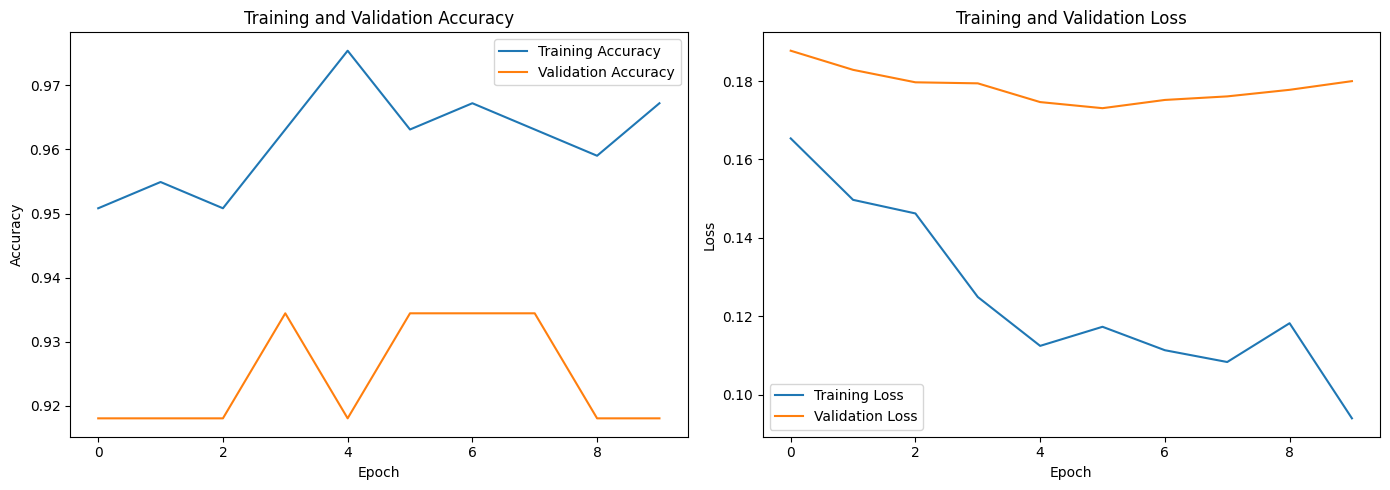

In [ ]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history_df["accuracy"], label="Training Accuracy")
axes[0].plot(history_df["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Loss
axes[1].plot(history_df["loss"], label="Training Loss")
axes[1].plot(history_df["val_loss"], label="Validation Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_processed,
    y_test,
    verbose=0
)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Test Accuracy (%): {test_accuracy * 100:.2f}%")

Final Test Accuracy: 0.8571
Final Test Loss: 0.3634
Test Accuracy (%): 85.71%


In [ ]:
y_probability = model.predict(
    X_test_processed,
    verbose=0
).ravel()

y_pred = (y_probability >= 0.5).astype(int)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 77


In [ ]:
print("Classification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=["Low", "High"],
    zero_division=0
))

Classification Report
              precision    recall  f1-score   support

         Low       0.82      0.93      0.87        40
        High       0.91      0.78      0.84        37

    accuracy                           0.86        77
   macro avg       0.86      0.85      0.86        77
weighted avg       0.86      0.86      0.86        77



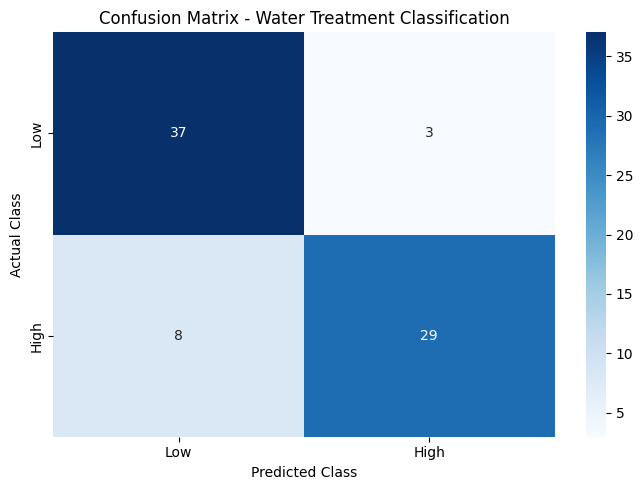

Confusion Matrix:
[[37  3]
 [ 8 29]]


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "High"],
    yticklabels=["Low", "High"]
)

plt.title("Confusion Matrix - Water Treatment Classification")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [ ]:
model.save("water_treatment_classifier.keras")

print("Model saved successfully.")

Model saved successfully.
